## Idea of this notebook

- Do maps as is done in the previous notebook from a meeting on April 7, 2026
- Idea will be to look at the map-space contributions to the budgets in heat and in salt
- Start from the derivation of termsT3D and termsS3D

In [34]:
# setup

# auto-reload edited modules
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.insert(0, "/home/mmurakami/crios_backups/an_helper_functions")

# run the script into the curre nt kernel (vars/functions become available)
%run -i "/home/mmurakami/crios_backups/an_helper_functions/prep_grid_aste_90.py"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
(450, 90)
RAC2d (40500,)
(100,)


In [35]:

from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

In [36]:
import matplotlib.colors as mcolors
from create_aste90_layers import create_layers_totalTHETA,create_layers_totalSALT
from create_aste90_layers import bin_3d_term_to_TS,create_TS_mesh
from scipy.ndimage import binary_dilation

In [37]:
from plotting_helpersmini import SI_masked                  # for the contour line of the sea ice
from plotting_helpersmini import plot_budget_miniaste
from plotting_helpersmini import plot_theta_salt_maps_miniaste

In [38]:
dirroot = "/scratch3/atnguyen/aste_90x150x60/"
dirgrid = dirroot + "GRID_real8/"
dirgridnb = dirroot + "GRID_noblank/"
runstr= "run_c68v_heffmosm3x_layers_lessmem1_viscAHp5em2_it0000_pk0000000001/"
layers_path = dirroot + runstr
extL = "LAYERS"
dirmask = dirroot + "run_template/input_maskTransport/"
dirbudg = layers_path + "diags/BUDG/"
dirdiags = dirbudg
dirstate = layers_path + "diags/STATE/"
dirlayers = layers_path + "diags/LAYERS/"
dirtrsp = layers_path + "diags/TRSP/"

In [39]:
dirlayers

'/scratch3/atnguyen/aste_90x150x60/run_c68v_heffmosm3x_layers_lessmem1_viscAHp5em2_it0000_pk0000000001/diags/LAYERS/'

In [40]:
# try to use rdmds
fileprefix = "/scratch3/atnguyen/aste_90x150x60/"
extBasin='run_template/input_maskTransport/'
filename = fileprefix + extBasin + "GATE_transports_v2_mskBasin.bin"
ind = np.fromfile(filename, dtype=np.int32)  # auto-reads .meta for shape/dtype/order
orig_shape = (ind.shape)

ind2d = ind.reshape(ny,nx)

In [41]:
# we need to also create the theta and salt bins for this area
tsstr = np.array(["0000000003","0000000004"])
t2 = int(tsstr[1]) # for the offline version
print(ts2dte(t2, deltat=1800, startyr=2015, startmo=1, startdy=1))

2015-01-01 02:00:00


In [42]:
# load the mask in 1D to get the points from offline

# try to use rdmds
fileprefix = "/scratch3/atnguyen/aste_90x150x60/"
extBasin='run_template/input_maskTransport/'
filename = fileprefix + extBasin + "GATE_transports_v2_mskBasin.bin"
ind = np.fromfile(filename, dtype=np.int32)  # auto-reads .meta for shape/dtype/order
orig_shape = (ind.shape)
ind2d = ind.reshape(ny,nx)
mymsk = np.full((ny,nx),np.nan)
mymsk[ind2d == 57408.0] = 1
# make this smaller
mymsk[:,27:50] = np.nan
mymsk[:160,12:30] = np.nan
mymsk[160:163,15:30] = np.nan
ind = ind.reshape(ny,nx)
mymsk = np.full((ny,nx),np.nan)
mymsk[ind == 57408.0] = 1
mymsk[:,27:50] = np.nan
mymsk[:160,12:30] = np.nan
mymsk[160:163,15:30] = np.nan

# load the indices for layers
mymsk_1d = mymsk.reshape(orig_shape, order='C')
mymsk_1dtile = np.tile(mymsk_1d[np.newaxis,:],(nT-1,1))
# mymsk3d.shape
# hf2dtile.shape
iwet_mine = np.where(~np.isnan(mymsk_1d))
iwet_mine[0].shape
iwet_mine = iwet_mine[0]   # this is already the 1D array of wetpoints to use, we can add these below by indexing

In [43]:
landmsk = np.zeros((ny,nx))
landmsk[np.isnan(mygrid['hFacC'][0])] = 1
land_dataf3 = get_aste_faces(landmsk,nfx,nfy).f3[0]
land_dataf3[land_dataf3==0]  = np.nan

## Load the tracer fields

In [44]:
# get the THETA as a time average
t2 = int(tsstr[1])
file_name = "state_3d_set1"
meta_state_3d_set1 = parsemeta(dirstate + file_name + "." + tsstr[0] + ".meta")
fldlist = np.array(meta_state_3d_set1["fldList"])
varnames = np.array(["THETA","SALT"])
recs = np.array([])
for var in varnames:
    irec = np.where(fldlist == var)
    recs = np.append(recs, irec[0][0])
THETA,its,meta = rdmds(os.path.join(dirstate, file_name),t2,returnmeta=True,rec=recs[0])
SALT,its,meta = rdmds(os.path.join(dirstate, file_name),t2,returnmeta=True,rec=recs[1])

THETA = THETA.reshape(nz, ny, nx) #* np.tile(mymsk[np.newaxis,:,:],(nz,1,1))
SALT  = SALT.reshape(nz, ny, nx) #* np.tile(mymsk[np.newaxis,:,:],(nz,1,1))
#SALT[SALT==0] = np.nan
#THETA[THETA==0] = np.nan


In [45]:
SI_masked, SI_JFM, metaSI = SI_masked(
    tsstr,
    dirState=dirstate, ny=ny, nx=nx, nfx=nfx, nfy=nfy,
    landmsk=landmsk, mymsk=mymsk,  # mymsk not used here except you might want it later
    land_buffer_iters=1,
)

In [46]:
# check what this includes
# plt.pcolormesh(SI_masked)

In [47]:
from plotting_helpersmini import plot_theta_salt_maps_miniaste

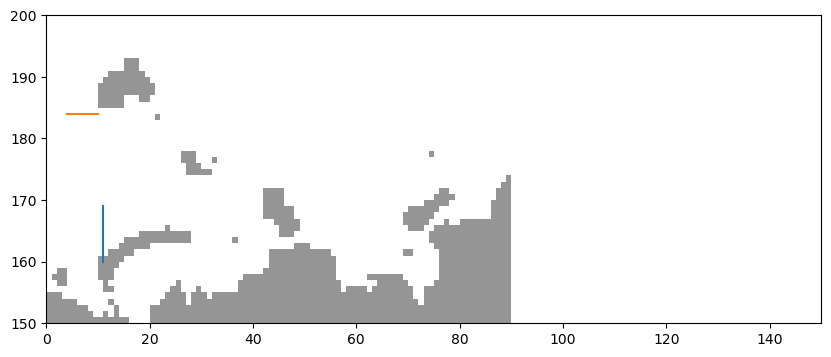

In [48]:
plt.pcolormesh(THETA[0] * mymsk)
plt.pcolormesh(landmsk,cmap="Greys",vmin=0,vmax=2)
x_section = np.arange(160,170,1)
y_section = np.full_like(x_section,11)
plt.plot(y_section,x_section)

y_section2 = np.arange(4,11,1)
x_section2 = np.full_like(y_section2,184)
plt.plot(y_section2,x_section2)
plt.xlim(0,150)
plt.ylim(150,200)

section_mask = np.full((ny,nx),np.nan)
section_mask[x_section2,y_section2] = 1
section_mask[x_section,y_section] = 1


In [49]:
SIarea_frac, its, meta = rdmds(os.path.join(dirstate, "state_2d_set1"),
            str(t2),
            returnmeta=True,
            rec=1
        )  # m^2/m^2
SIarea = np.asarray(SIarea_frac).reshape((ny, nx))
SIarea_map = np.full((nz,ny,nx),np.nan)
SIarea_map[0][SIarea>0] = 1

Saved figure to figs/TS_map_k15.png


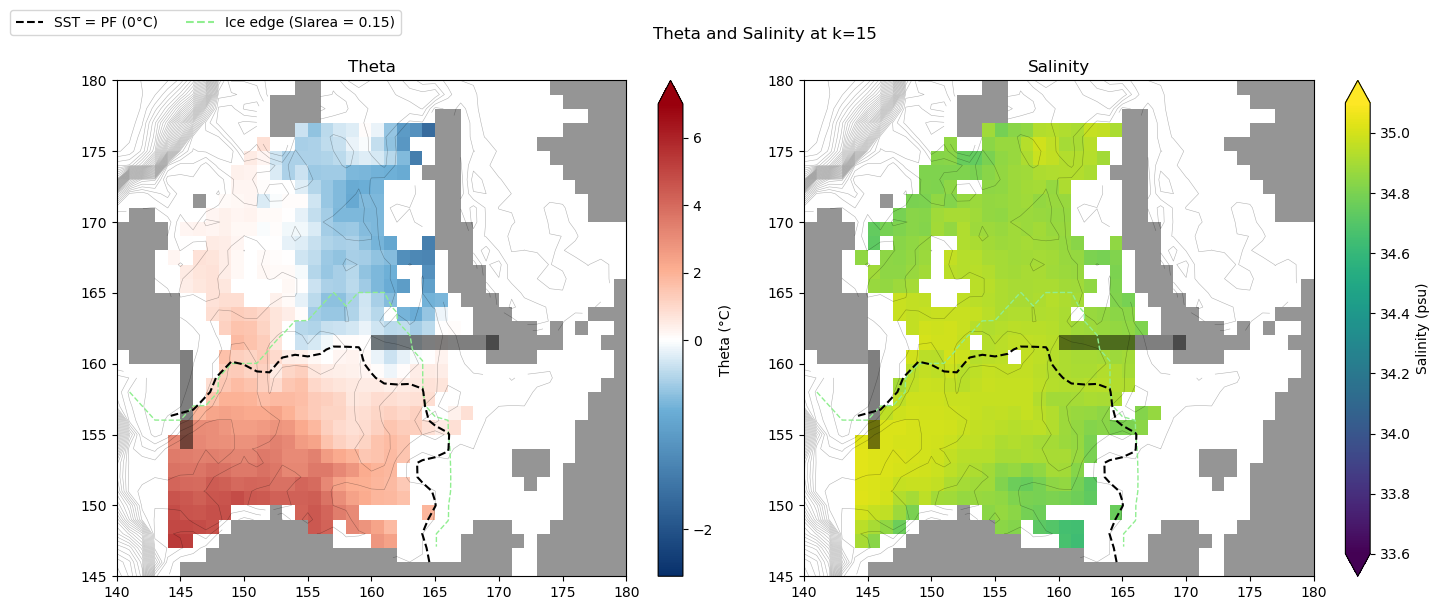

In [50]:
fig, axes = plot_theta_salt_maps_miniaste(
    theta=THETA,
    salt=SALT,
    mygrid=mygrid,
    mymsk=mymsk,
    SI_masked=SI_masked,
    landmsk=landmsk,
    nfx=nfx,
    nfy=nfy,
    get_aste_tracer=get_aste_tracer,
    klev=15,
    theta_vmin=-2.5,
    theta_vmax=7,
    salt_vmin=33.6,
    salt_vmax=35.1,
    section_mask = section_mask,
    save = True,
    save_name = "TS_map_k15.png"
)

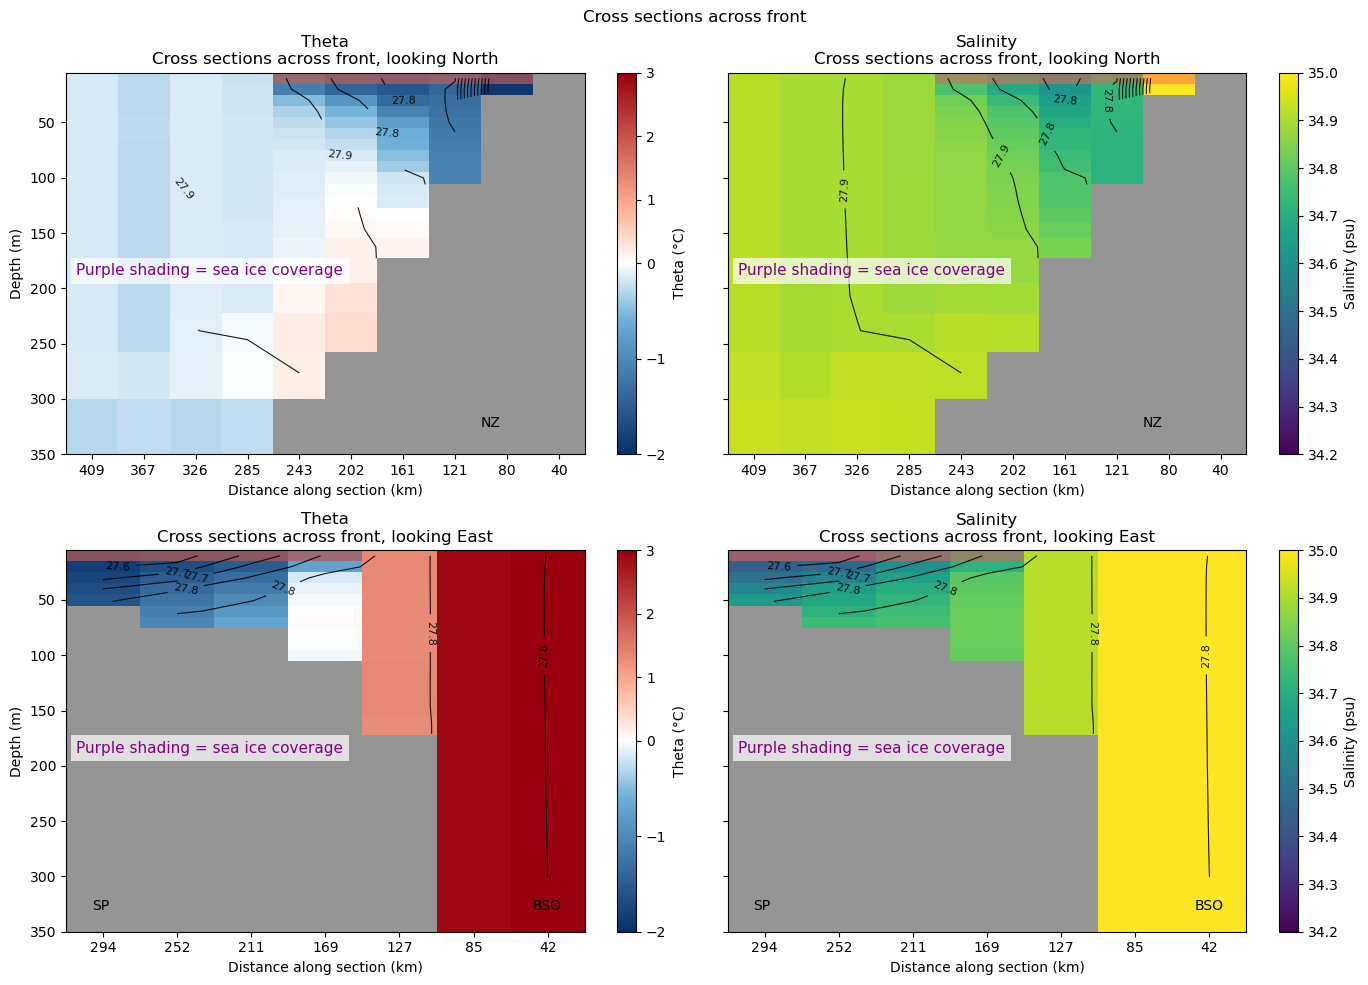

In [51]:


# -------------------------
# colormaps / plotting ranges
# -------------------------
theta_cmap = LinearSegmentedColormap.from_list(
    "custom_theta_rwbr",
    [
        (0.00, "#08306b"),
        (0.35, "#6baed6"),
        (0.50, "#ffffff"),
        (0.65, "#fcae91"),
        (1.00, "#99000d"),
    ],
)
theta_norm = TwoSlopeNorm(vmin=-2, vcenter=0.0, vmax=3)

salt_vmin, salt_vmax = 34.2, 35.0
rho_clevs = np.arange(27.0, 28.3, 0.05)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)

sections = [
    (x_section,  y_section,  "Cross sections across front, looking North", "NZ"),
    (x_section2, y_section2, "Cross sections across front, looking East",  "SP"),
]


for row, (xs, ys, row_title, corner_label) in enumerate(sections):
    
    theta_sec = THETA[:, xs, ys].copy()   # shape (nz, npts)
    salt_sec  = SALT[:,  xs, ys].copy()   # shape (nz, npts)
    ice_sec = SIarea_map[:,xs,ys].copy()
    z = np.cumsum(mygrid["DRF"].squeeze())  # depth (m)

    land_hfc = mygrid["hFacC"][:, xs, ys]
    land_sec = np.full_like(land_hfc, np.nan, dtype=float)
    land_sec[np.isnan(land_hfc)] = 1

    yc_sec = mygrid["DYG"][xs, ys]

    # cumulative distance in meters -> km
    dist_km = np.cumsum(yc_sec) / 1000.0
    dist_km = np.round(dist_km)

    sec_idx = np.arange(len(yc_sec))

    # clean zeros
    salt_sec[salt_sec == 0] = np.nan
    theta_sec[theta_sec == 0] = np.nan

    # density anomaly
    rho_sec = gsw.rho(salt_sec, theta_sec, 0) - 1000

    fields = [
        (theta_sec, "Theta", "Theta (°C)", theta_cmap, theta_norm, None, None),
        (salt_sec,  "Salinity", "Salinity (psu)", "viridis", None, salt_vmin, salt_vmax),
    ]

    for col, (field, title, cbar_label, cmap, norm, vmin, vmax) in enumerate(fields):
        ax = axes[row, col]

        if norm is not None:
            pcm = ax.pcolormesh(
                sec_idx,
                z,
                field,
                shading="auto",
                cmap=cmap,
                norm=norm,
            )
        else:
            pcm = ax.pcolormesh(
                sec_idx,
                z,
                field,
                shading="auto",
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
            )

        # gray land
        ax.pcolormesh(
            sec_idx,
            z,
            land_sec,
            cmap="Greys",
            vmin=0,
            vmax=2,
            shading="auto",
        )

        # sea ice as green
        ice_pcm = ax.pcolormesh(
            sec_idx,
            z,
            ice_sec,
            cmap="Reds",
            vmin=0,
            vmax=2,
            shading="auto",
            alpha=0.5
        )

        # density contours
        cs = ax.contour(
            sec_idx,
            z,
            rho_sec,
            levels=rho_clevs,
            colors="k",
            linewidths=0.8,
            alpha=0.9,
        )
        ax.clabel(cs, fmt="%.1f", fontsize=8)
        ax.text(
            0.02, 0.5,
            "Purple shading = sea ice coverage",
            transform=ax.transAxes,
            fontsize=11,
            color="purple",
            ha="left",
            va="top",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
        )

        tick_idx = sec_idx[::max(1, len(sec_idx)//8)]
        ax.set_xticks(tick_idx)
        ax.set_xticklabels(dist_km.astype(int)[::max(1, len(sec_idx)//8)])

        # annotations
        if row == 0:
            ax.text(0.8, 0.1, corner_label, transform=ax.transAxes, va="top")
        else:
            ax.text(0.05, 0.05, corner_label, transform=ax.transAxes, va="bottom", ha="left")
            ax.text(0.9, 0.05, "BSO", transform=ax.transAxes, va="bottom", ha="left")


        ax.invert_yaxis()
        ax.invert_xaxis()
        ax.set_ylim(350, 5)

        ax.set_title(f"{title}\n{row_title}")
        ax.set_xlabel("Distance along section (km)")
        plt.colorbar(pcm, ax=ax, label=cbar_label)

    axes[row, 0].set_ylabel("Depth (m)")

plt.suptitle("Cross sections across front")
plt.tight_layout()
plt.savefig("figs/cross_sections.png",dpi=300)

In [52]:
# make a new version of this function to add the cross section

## Load the contributions to the budget

In [53]:
# now load the contributions to T and S
dt = 1800 # standard for miniaste here for one time step

MsumT,termsT3D = create_layers_totalTHETA(tsstr,mygrid,myparms,dirdiags,dirstate,layers_path,mymsk,nz,ny,nx,nfx,nfy,dt,boundsT,boundsS,mapping=True,debug=False)
MsumS,termsS3D = create_layers_totalSALT(tsstr,mygrid,myparms,dirdiags,dirstate,layers_path,mymsk,nz,ny,nx,nfx,nfy,dt,boundsT,boundsS,mapping=True,debug=False)
# these have advh, advr, dfh, dfr, surf, kpp, tend and have not been normalized

In [54]:
# add the SI tracer to this



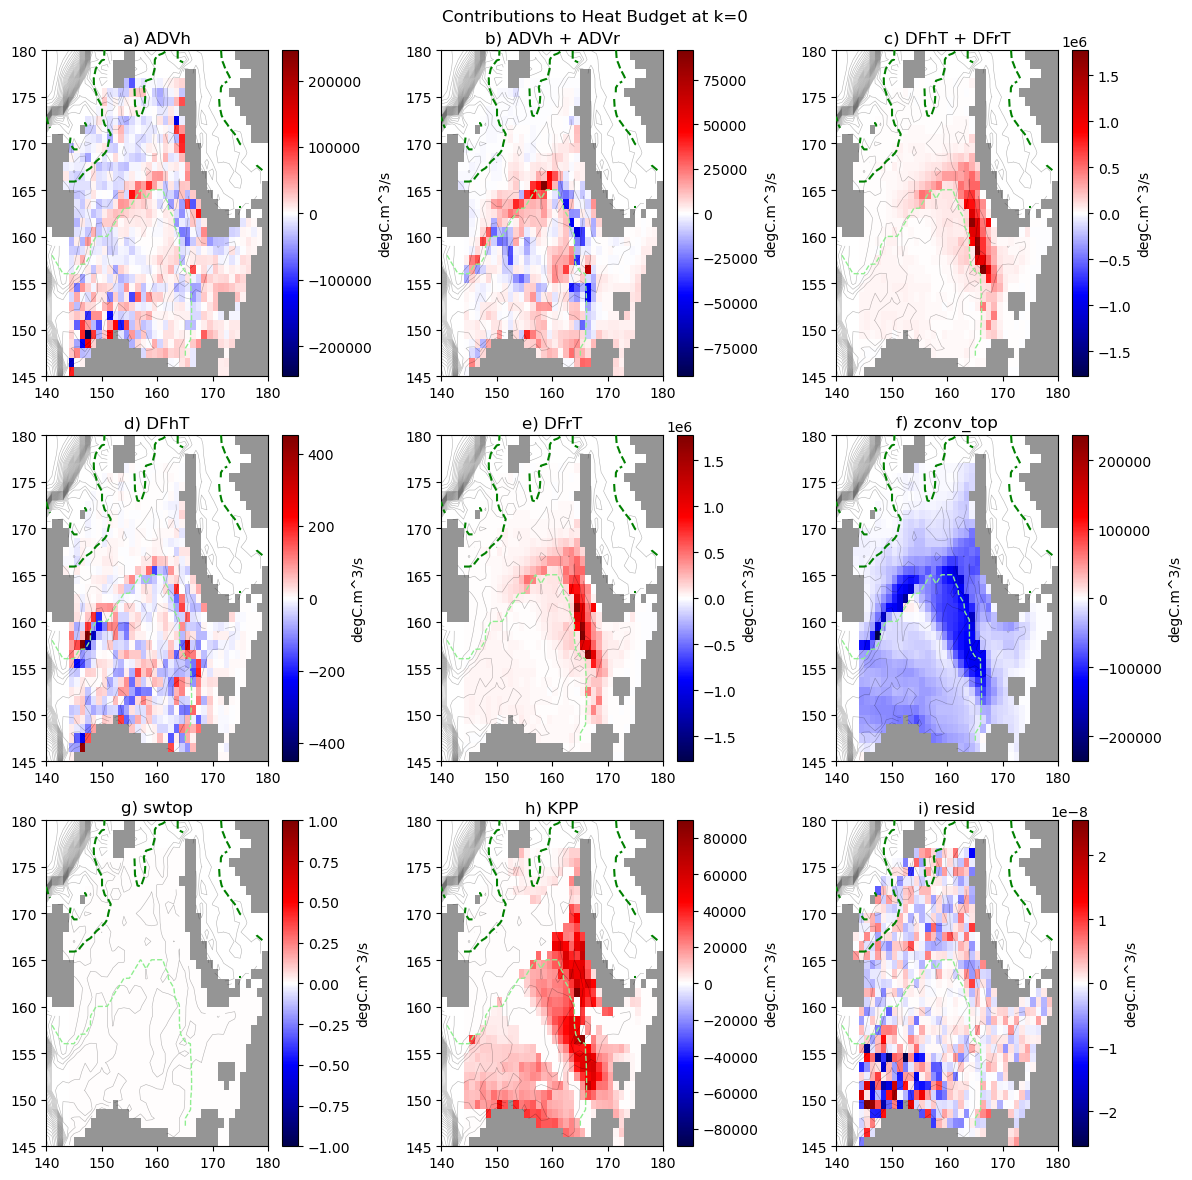

In [55]:

fig, axes = plot_budget_miniaste(
    terms3D=termsT3D,
    mygrid=mygrid,
    mymsk=mymsk,
    landmsk=landmsk,
    SI_masked=SI_masked,
    nfx=nfx,
    nfy=nfy,
    get_aste_tracer=get_aste_tracer,
    klev=0,
    kind="T",
)

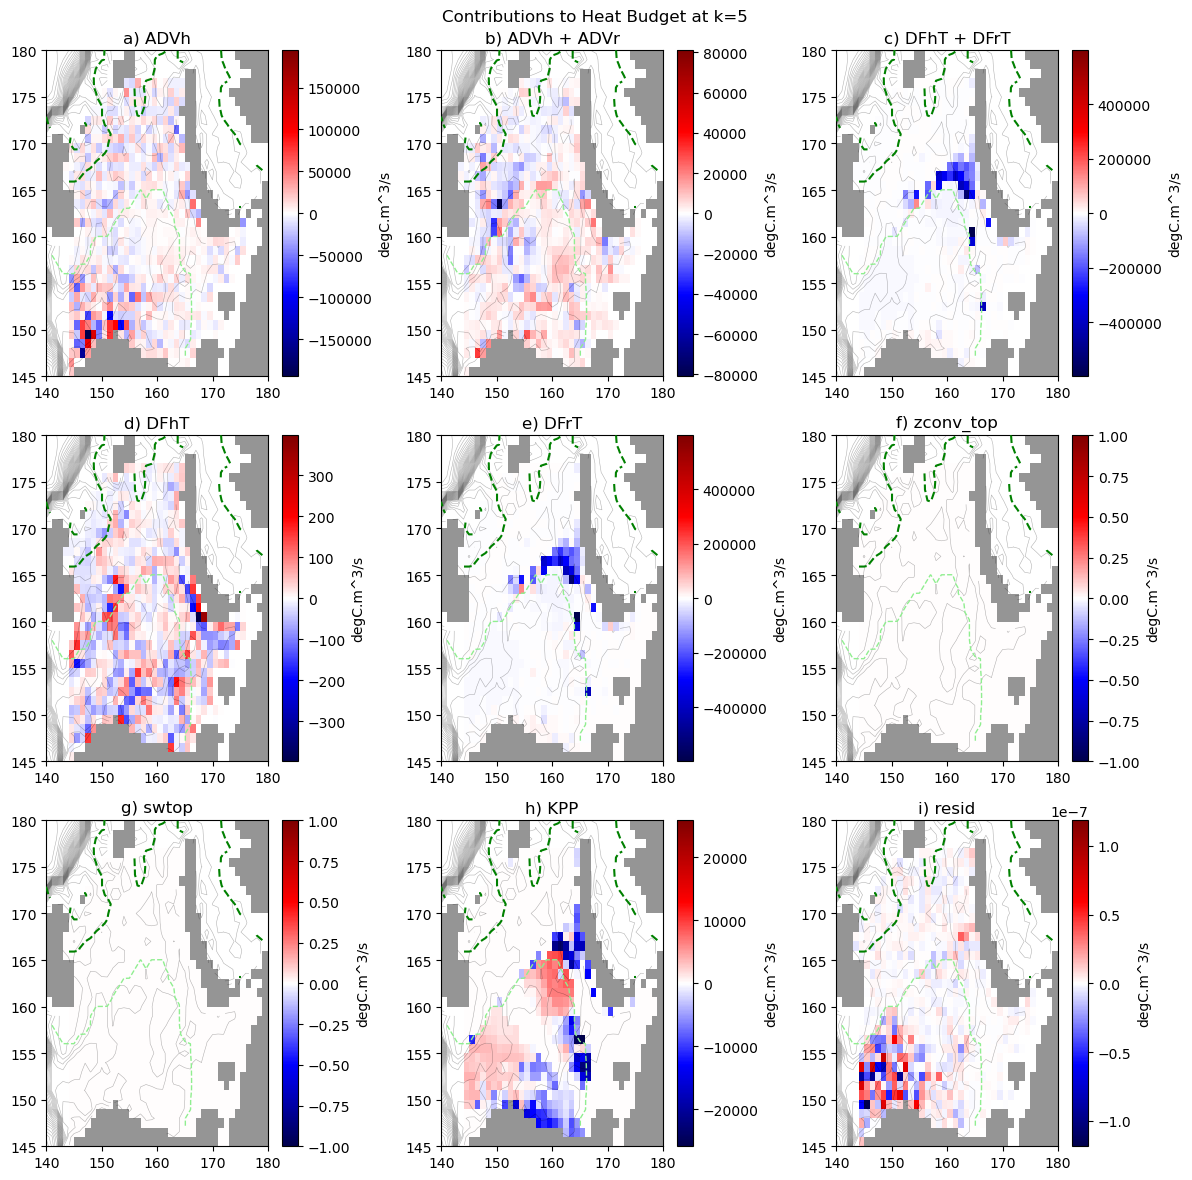

In [23]:

fig, axes = plot_budget_miniaste(
    terms3D=termsT3D,
    mygrid=mygrid,
    mymsk=mymsk,
    landmsk=landmsk,
    SI_masked=SI_masked,
    nfx=nfx,
    nfy=nfy,
    get_aste_tracer=get_aste_tracer,
    klev=5,
    kind="T",
)

## for the salt budget

Saved figure to figs/miniaste_salt_budget_k0.png


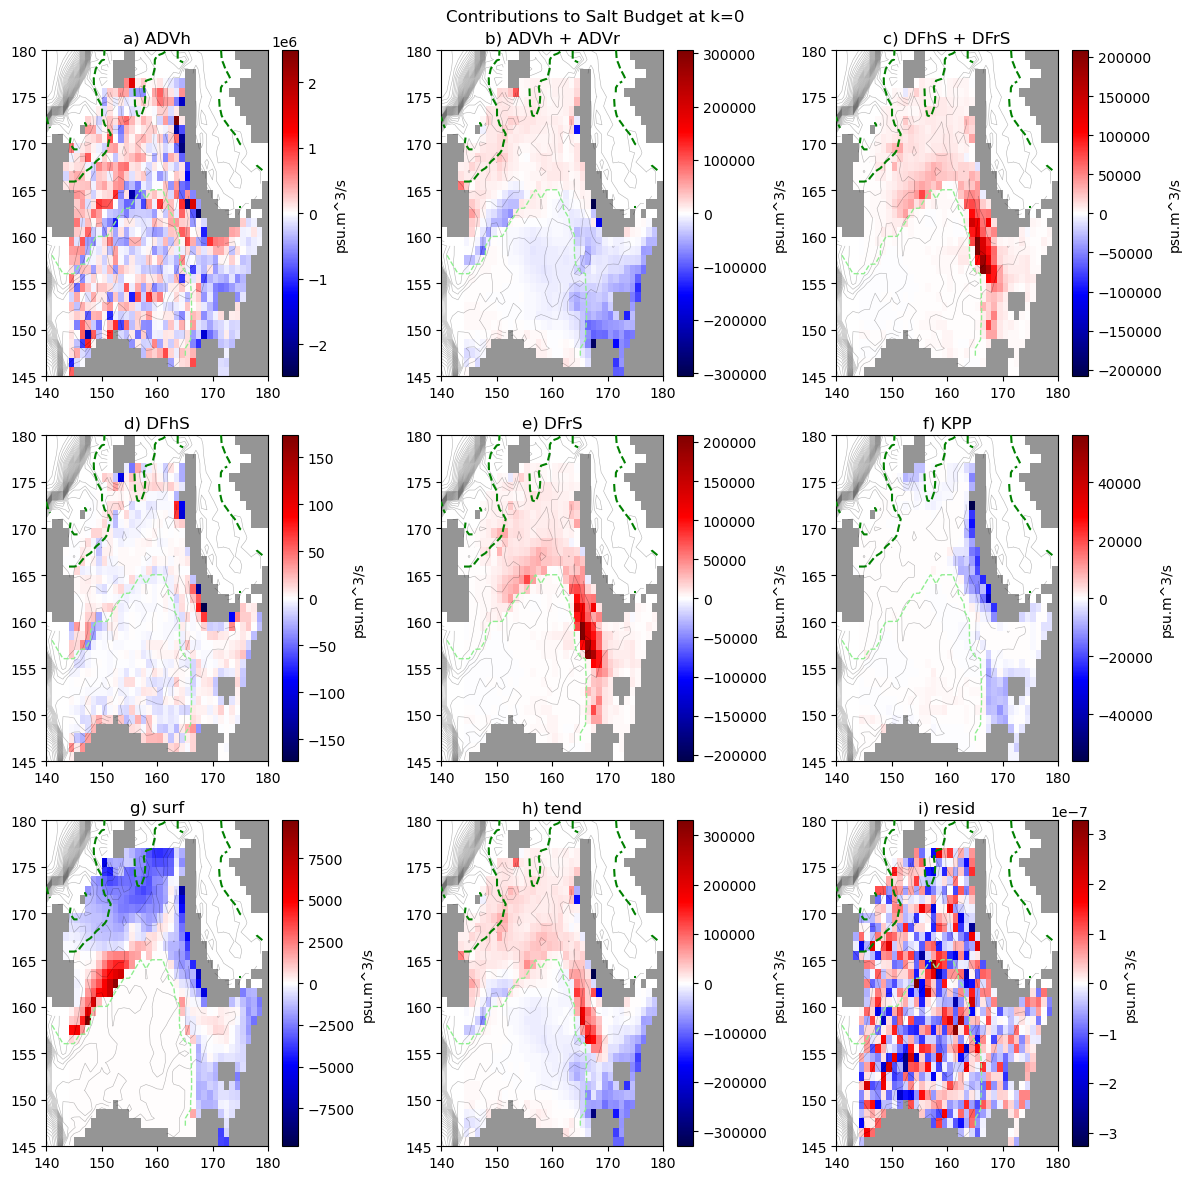

In [24]:

fig, axes = plot_budget_miniaste(
    terms3D=termsS3D,
    mygrid=mygrid,
    mymsk=mymsk,
    landmsk=landmsk,
    SI_masked=SI_masked,
    nfx=nfx,
    nfy=nfy,
    get_aste_tracer=get_aste_tracer,
    klev=0,
    kind="S",
    save = True
)

Saved figure to figs/miniaste_salt_budget_k15.png


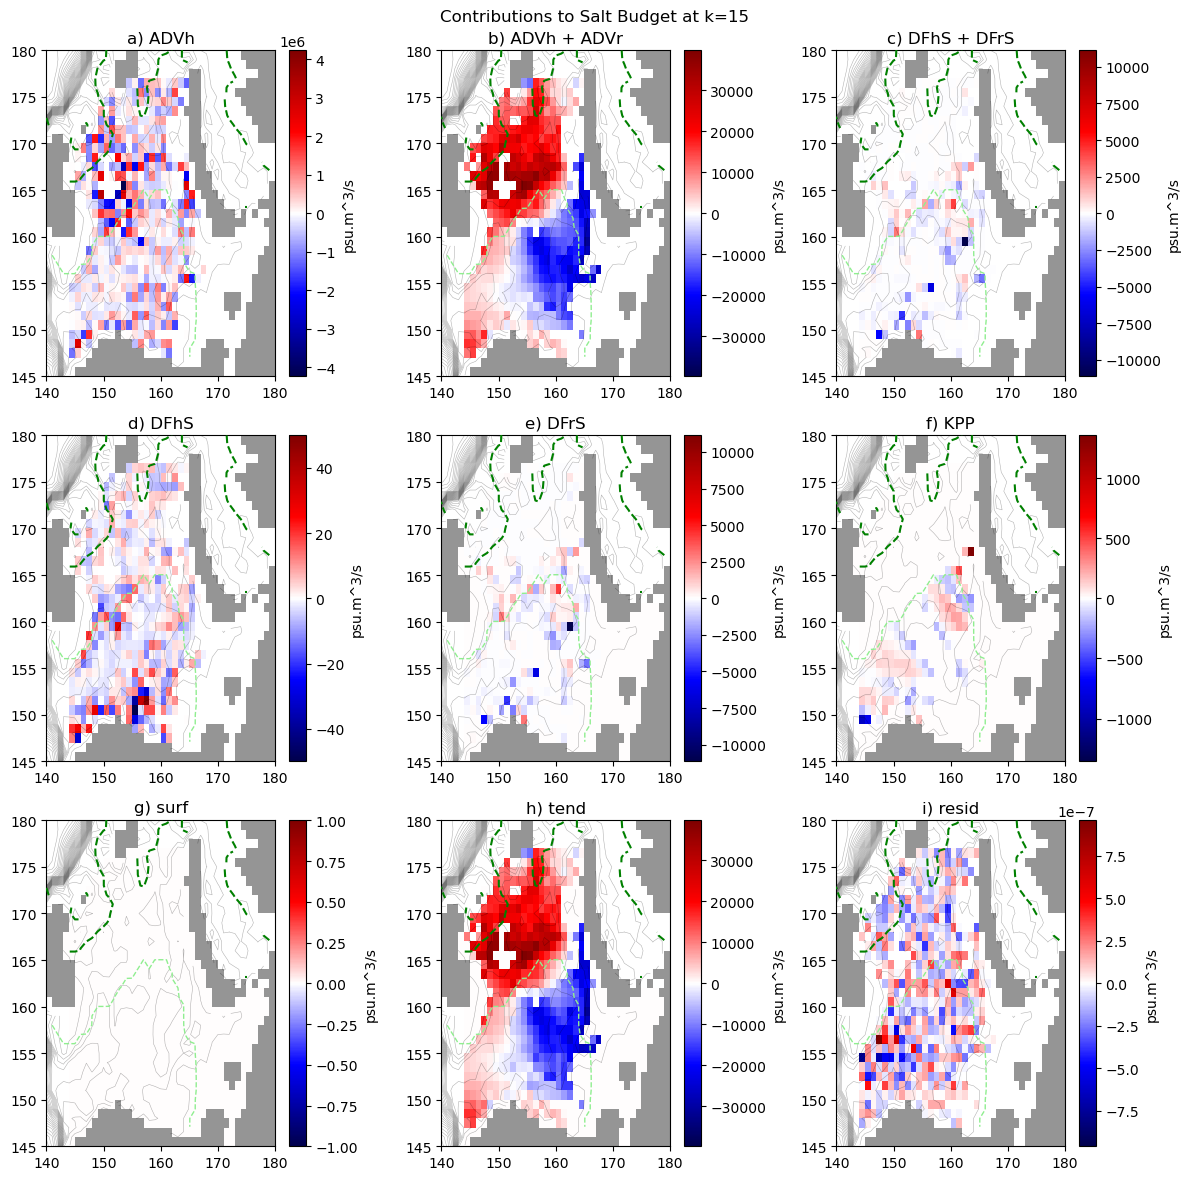

In [25]:

fig, axes = plot_budget_miniaste(
    terms3D=termsS3D,
    mygrid=mygrid,
    mymsk=mymsk,
    landmsk=landmsk,
    SI_masked=SI_masked,
    nfx=nfx,
    nfy=nfy,
    get_aste_tracer=get_aste_tracer,
    klev=15,
    kind="S",
    save = True,
)

In [26]:
# it would also be useful to plot a small cross section across where the transformations are greatest in heat and salt
# from in tracer coordinates, this should be approx at x=168

## add cross sectional contributions of the budget to look at vertical mixing

In [56]:
from plotting_helpersmini import plot_budget_section

In [71]:
def plot_theta_salt_section(
    fields3D,
    x_section,
    y_section,
    mygrid,
    figsize=(12, 5),
    zmax=350,
    theta_cmap="RdYlBu_r",
    salt_cmap="coolwarm",
    rho_for_contours=None,
    rho_clevs=np.arange(27.0, 28.3, 0.05),
    suptitle="THETA and SALT along section",
    save=False,
    save_name="theta_salt_section.png",
):
    """
    Plot a 1x2 section:
      left  = THETA
      right = SALT

    Parameters
    ----------
    fields3D : dict
        Must contain keys "THETA" and "SALT", each shaped (nz, nx, ny)
        or consistent with [:, x_section, y_section].
    x_section, y_section : array-like
        Indices defining the section path.
    mygrid : dict
        Must contain "DRF". Optionally "DYG" for distance along section.
        Optionally "hFacC" for land masking.
    """

    required_keys = ["THETA", "SALT"]
    missing = [k for k in required_keys if k not in fields3D]
    if missing:
        raise KeyError(f"Missing required keys in fields3D: {missing}")

    x_section = np.asarray(x_section).astype(int)
    y_section = np.asarray(y_section).astype(int)

    if x_section.shape != y_section.shape:
        raise ValueError("x_section and y_section must have the same shape")

    # vertical coordinate
    z = np.cumsum(mygrid["DRF"].squeeze())

    # section distance
    if "DYG" in mygrid:
        dsec = mygrid["DYG"][x_section, y_section]
        dist_km = np.cumsum(dsec) / 1000.0
        dist_km = np.round(dist_km)
    else:
        dist_km = np.arange(len(x_section))

    sec_idx = np.arange(len(x_section))

    # land mask
    land_sec = None
    if "hFacC" in mygrid:
        hfac_sec = mygrid["hFacC"][:, x_section, y_section]
        land_sec = np.full_like(hfac_sec, np.nan, dtype=float)
        land_sec[np.isnan(hfac_sec) | (hfac_sec == 0)] = 1

    # section fields
    theta_sec = fields3D["THETA"][:, x_section, y_section].copy()
    salt_sec = fields3D["SALT"][:, x_section, y_section].copy()

    theta_sec[theta_sec == 0] = np.nan
    salt_sec[salt_sec == 0] = np.nan

    rho_sec = None
    if rho_for_contours is not None:
        rho_sec = rho_for_contours[:, x_section, y_section].copy()
        rho_sec[rho_sec == 0] = np.nan

    fig, axes = plt.subplots(1, 2, figsize=figsize, sharex=True, sharey=True)

    tick_step = max(1, len(sec_idx) // 6)
    tick_idx = sec_idx[::tick_step]
    tick_labels = dist_km.astype(int)[::tick_step]

    plot_defs = [
        ("THETA", theta_sec, theta_cmap, r"$^\circ$C"),
        ("SALT", salt_sec, salt_cmap, "PSU"),
    ]

    for ax, (title, field, cmap, cbar_label) in zip(axes, plot_defs):
        pcm = ax.pcolormesh(
            sec_idx,
            z,
            field,
            shading="auto",
            cmap=cmap,
        )

        if land_sec is not None:
            ax.pcolormesh(
                sec_idx,
                z,
                land_sec,
                cmap="Greys",
                vmin=0,
                vmax=2,
                shading="auto",
            )

        if rho_sec is not None:
            ax.contour(
                sec_idx,
                z,
                rho_sec,
                levels=rho_clevs,
                colors="k",
                linewidths=0.5,
                alpha=0.7,
            )

        ax.set_title(title)
        ax.set_xticks(tick_idx)
        ax.set_xticklabels(tick_labels)
        ax.invert_yaxis()
        ax.invert_xaxis()
        ax.set_ylim(zmax, 5)
        ax.set_xlabel("Distance along section (km)")
        plt.colorbar(pcm, ax=ax, label=cbar_label)

    axes[0].set_ylabel("Depth (m)")
    plt.suptitle(suptitle)
    plt.tight_layout()

    if save:
        os.makedirs("figs", exist_ok=True)
        save_path = os.path.join("figs", save_name)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved figure to {save_path}")

    return fig, axes

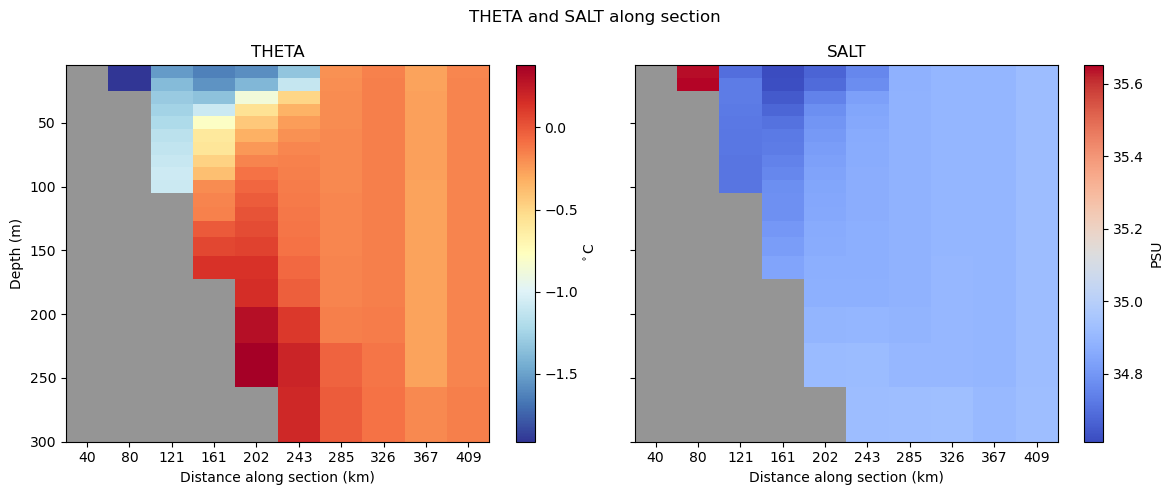

In [72]:
fig, axes = plot_theta_salt_section(
    fields3D={
        "THETA": THETA,
        "SALT": SALT,
    },
    x_section=x_section,
    y_section=y_section,
    mygrid=mygrid,
    zmax=300,
    save=False,
)

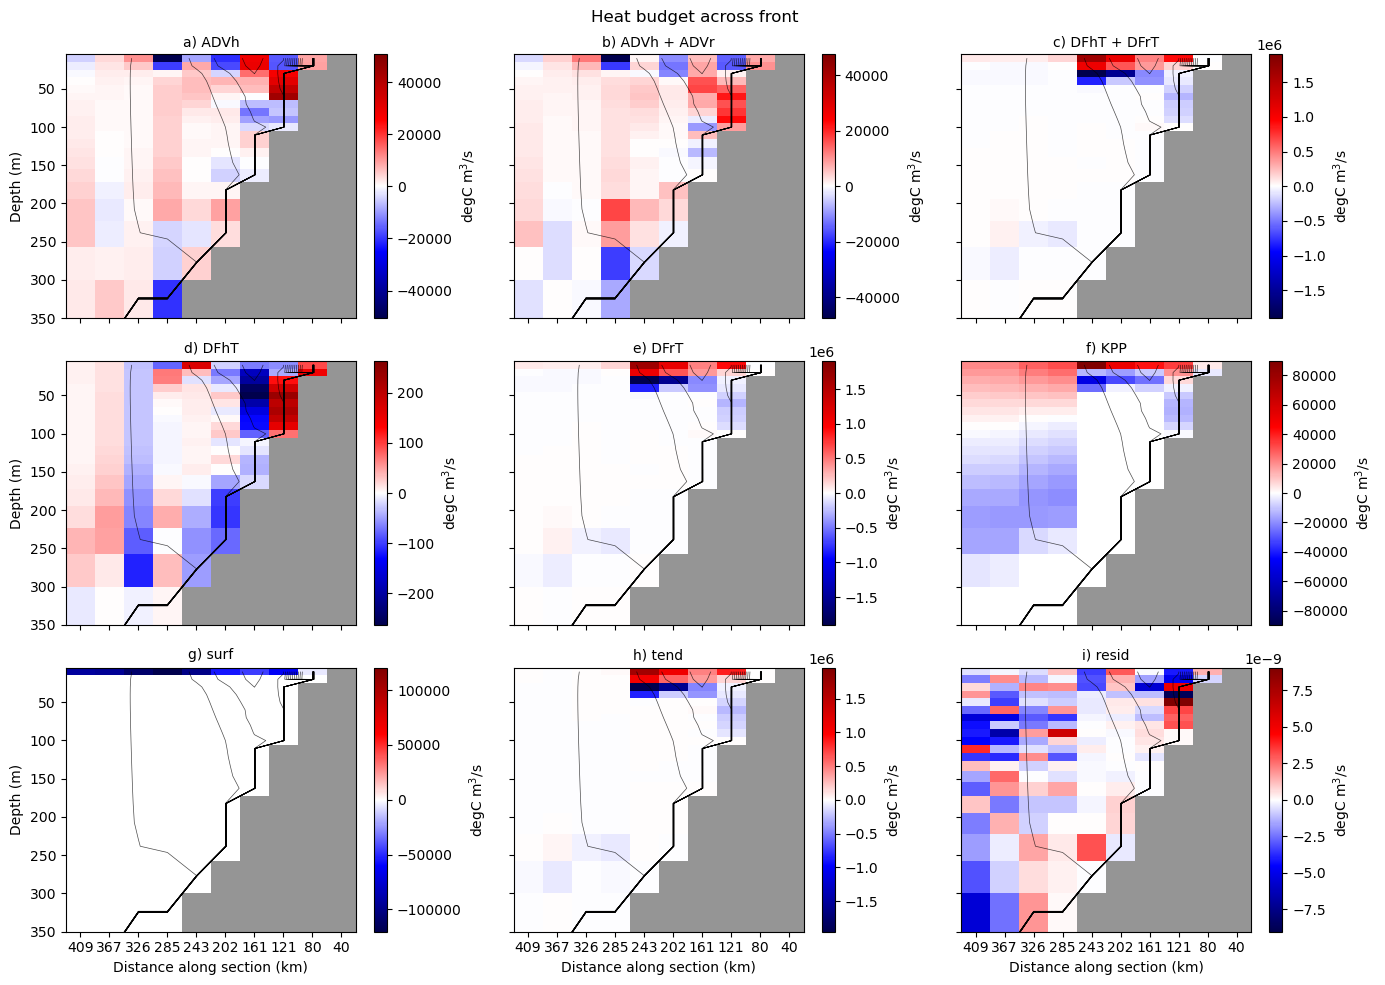

In [57]:
fig, axes = plot_budget_section(
    terms3D=termsT3D,
    x_section=x_section,
    y_section=y_section,
    mygrid=mygrid,
    kind="T",
    rho_for_contours=gsw.rho(SALT, THETA, 0) - 1000,
    zmax=350,
    suptitle="Heat budget across front",
)

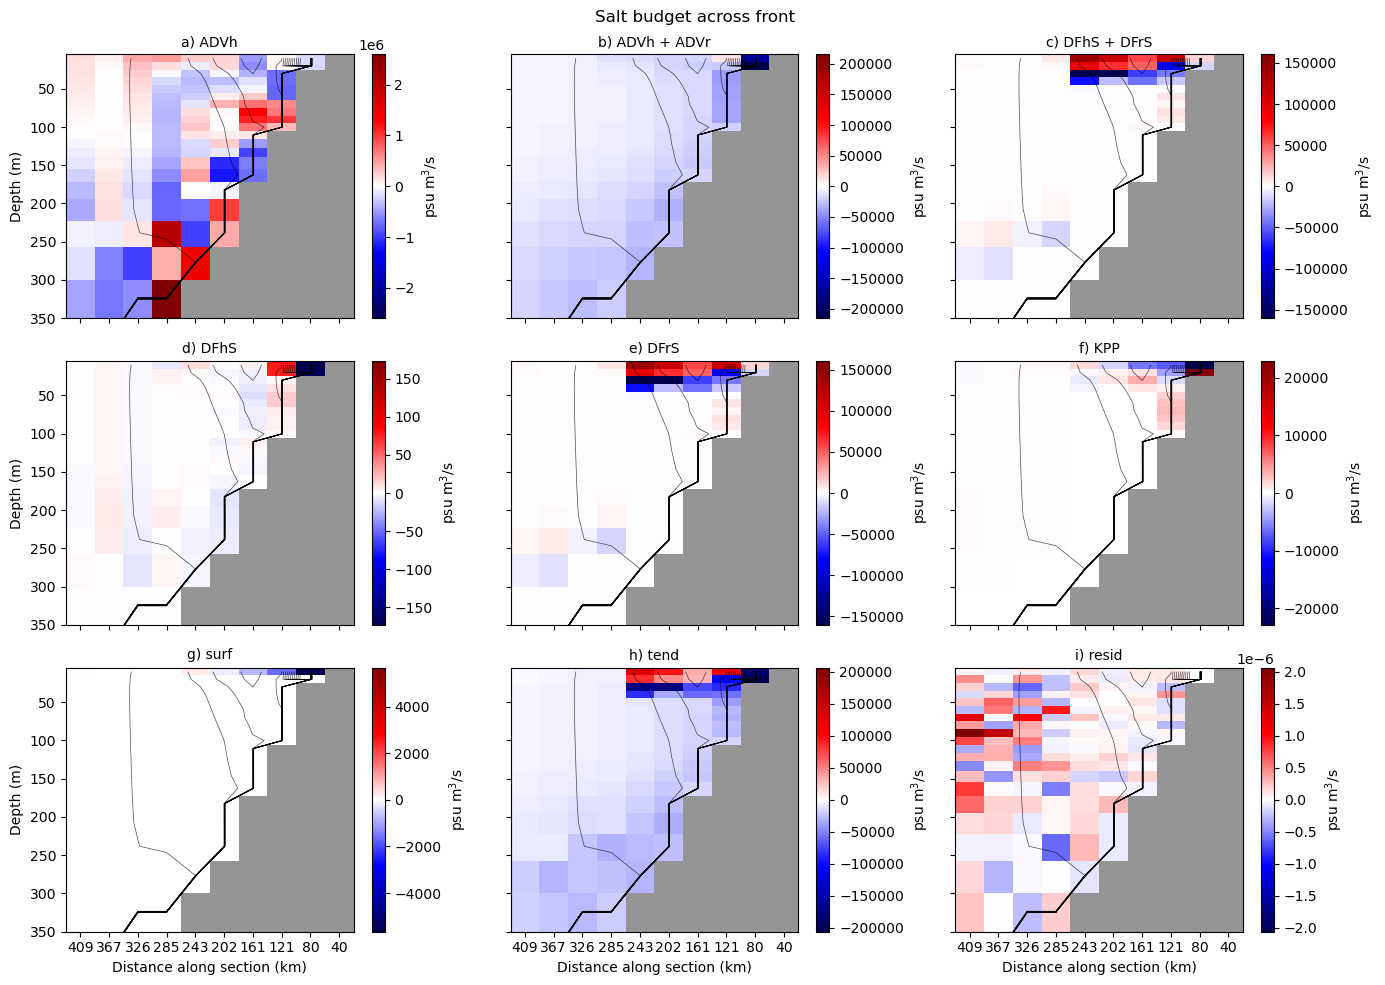

In [58]:
fig, axes = plot_budget_section(
    terms3D=termsS3D,
    x_section=x_section,
    y_section=y_section,
    mygrid=mygrid,
    kind="S",
    rho_for_contours=gsw.rho(SALT, THETA, 0) - 1000,
    zmax=350,
    suptitle="Salt budget across front",
)

## Add the surface term breakdown to this

In [62]:
from plotting_helpersmini import plot_budget_miniastefull

In [63]:
termsT3D.keys()

dict_keys(['ADVh', 'ADVr', 'DFhT', 'DFrT', 'surf', 'TFLUX', 'zconv_top', 'swtop', 'KPP', 'tend'])

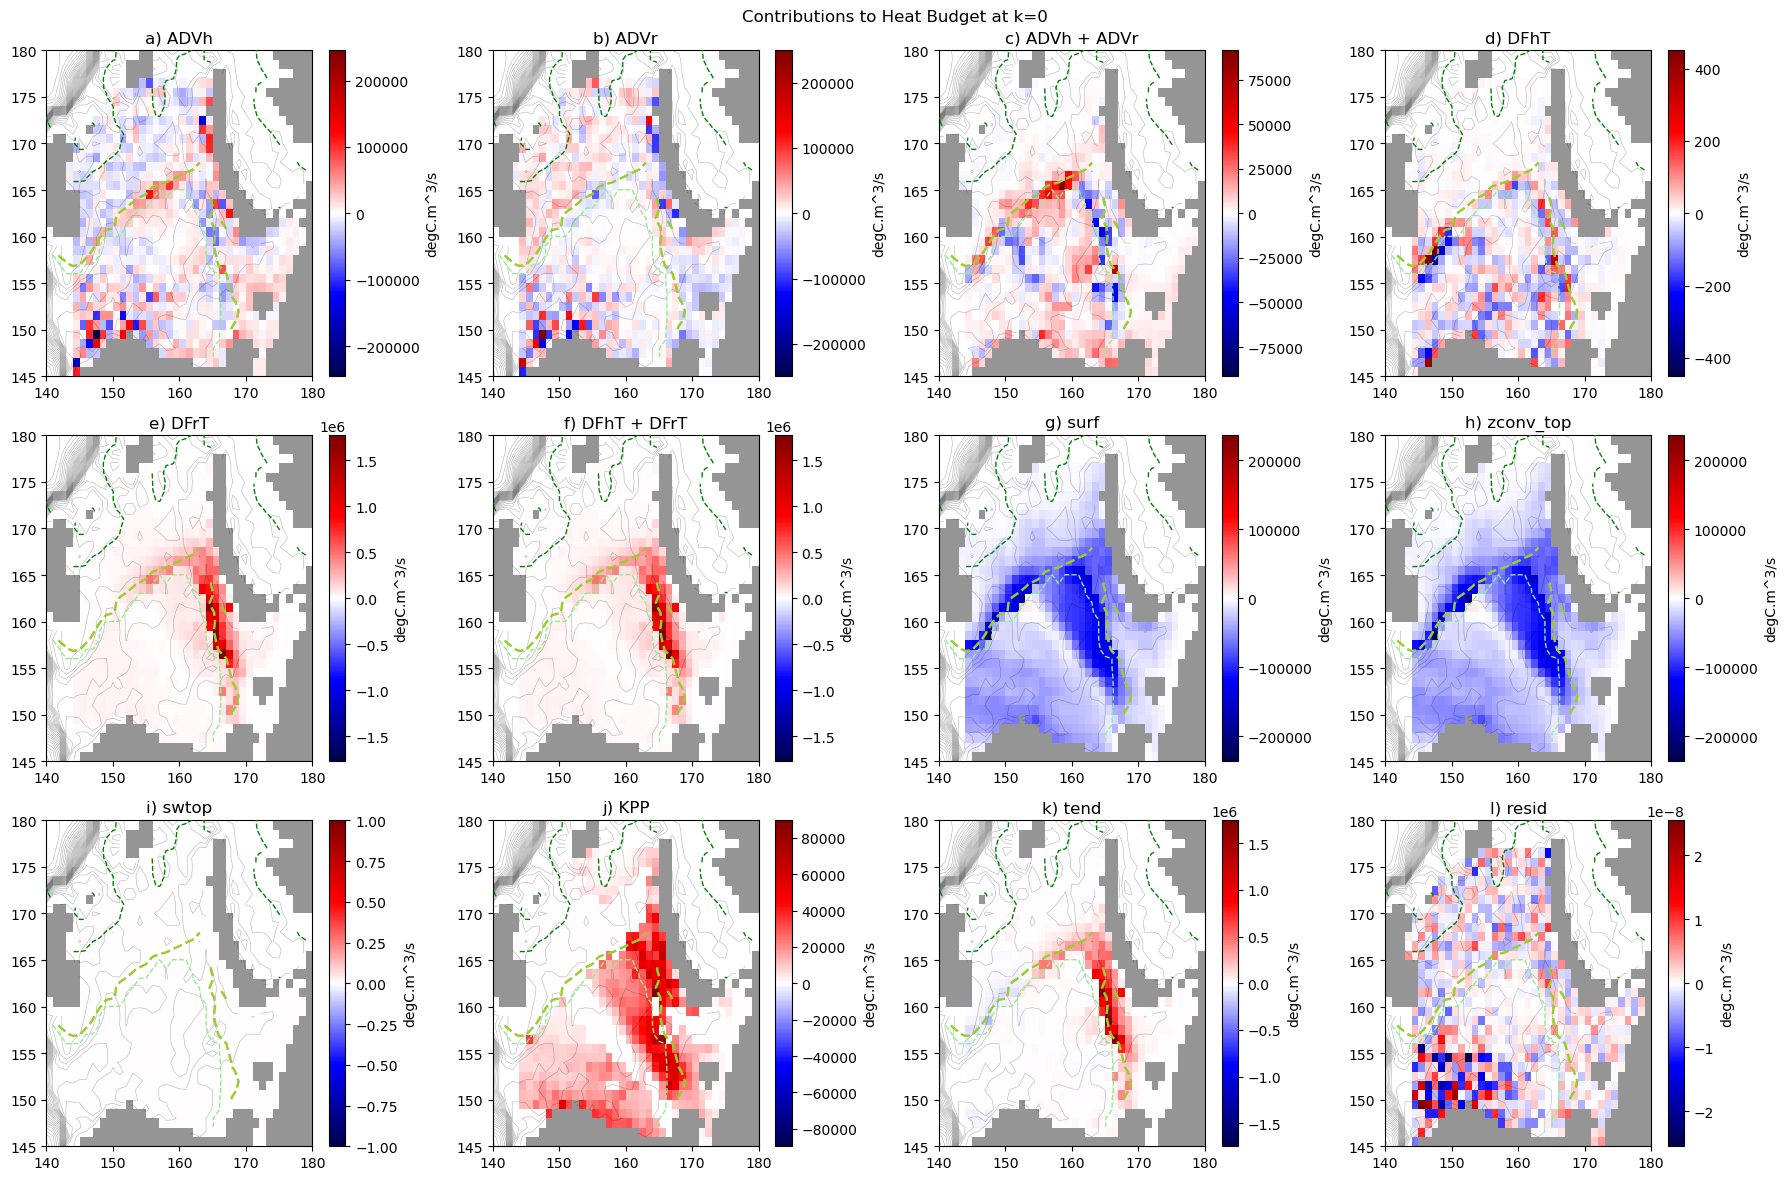

In [73]:

fig, axes = plot_budget_miniastefull(
    terms3D=termsT3D,
    mygrid=mygrid,
    mymsk=mymsk,
    landmsk=landmsk,
    SI_masked=SI_masked,
    nfx=nfx,
    nfy=nfy,
    get_aste_tracer=get_aste_tracer,
    klev=0,
    kind="T",
)

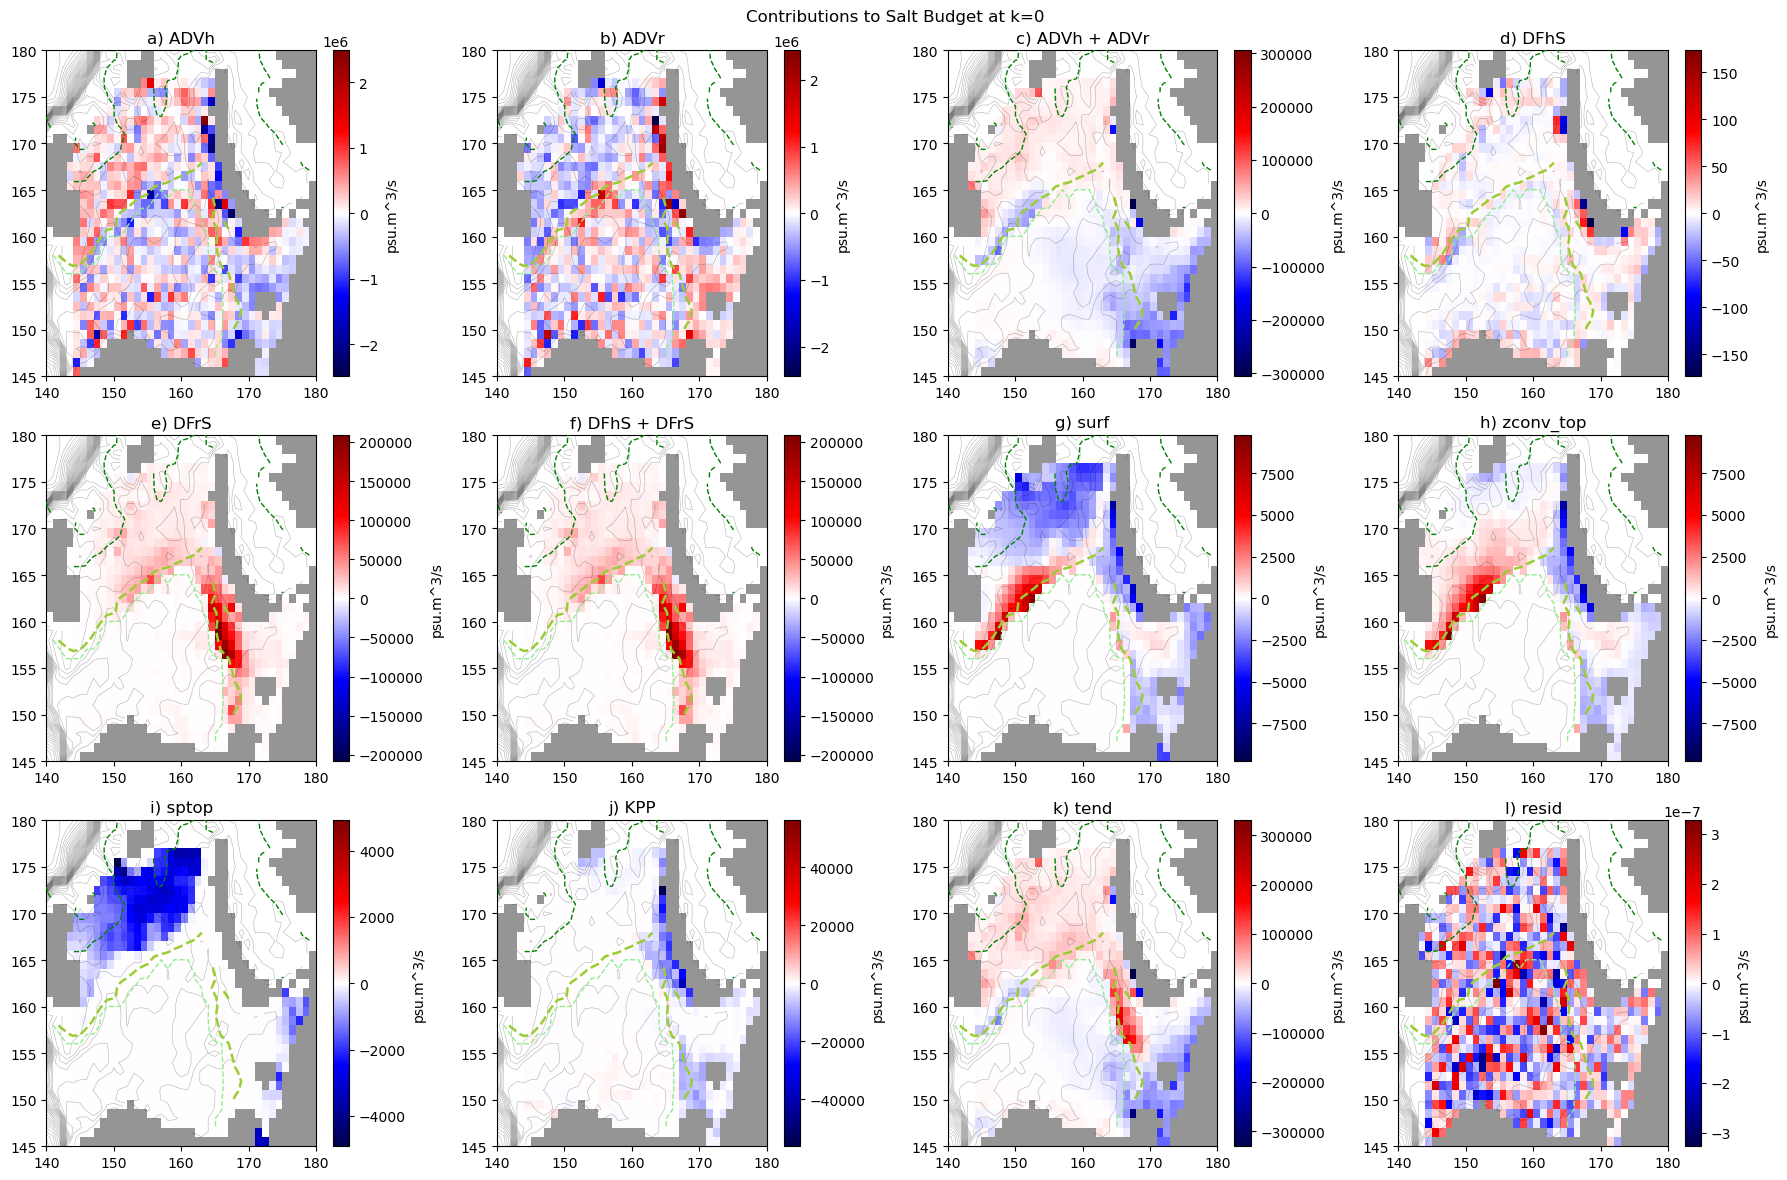

In [74]:

fig, axes = plot_budget_miniastefull(
    terms3D=termsS3D,
    mygrid=mygrid,
    mymsk=mymsk,
    landmsk=landmsk,
    SI_masked=SI_masked,
    nfx=nfx,
    nfy=nfy,
    get_aste_tracer=get_aste_tracer,
    klev=0,
    kind="S",
)